# Fraud Detection System

### Project Overview


This system analyzes credit card transactions and predicts whether a transaction is:
- Non-Fraud
- Fraud

experimented with multiple machine learning models to solve the fraud detection problem:
- Logistic Regression
- Random Forest
- XGBoost

### I. EDA

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import joblib

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../data/raw/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
print("Dataset Shape:", df.shape)

Dataset Shape: (284807, 31)


In [4]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [7]:
df.duplicated().sum()

1081

In [8]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [9]:
fraud_percentage = (df["Class"].value_counts()[1] / len(df)) * 100
print(f"Fraud Transactions Percentage: {fraud_percentage:.4f}%")

Fraud Transactions Percentage: 0.1727%


### II. Data Visualization

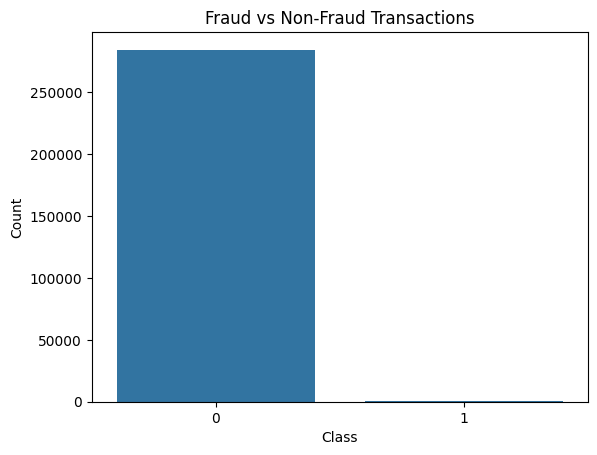

In [10]:
sns.countplot(x="Class", data=df)

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

#### Observation

The dataset is highly imbalanced, where fraudulent transactions represent a very small percentage of the total transactions.
This imbalance can negatively affect model performance and requires special handling during training.

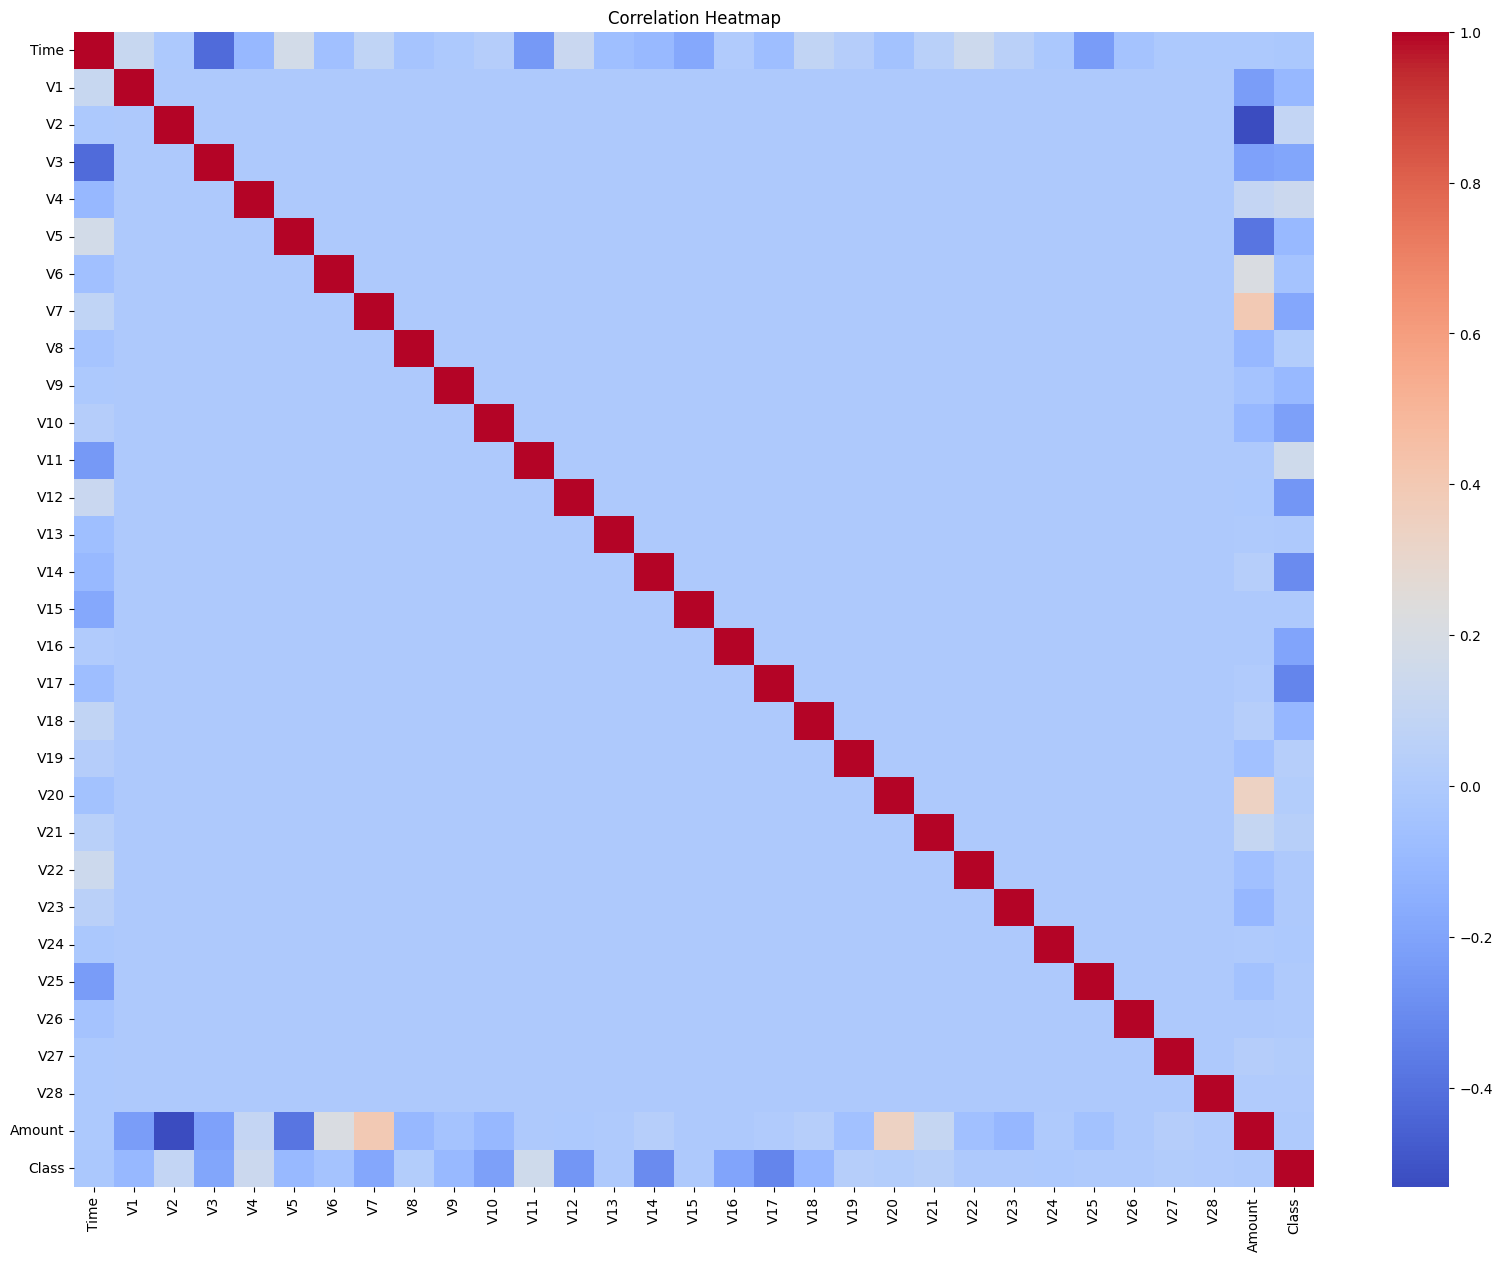

In [11]:
plt.figure(figsize=(20, 15))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

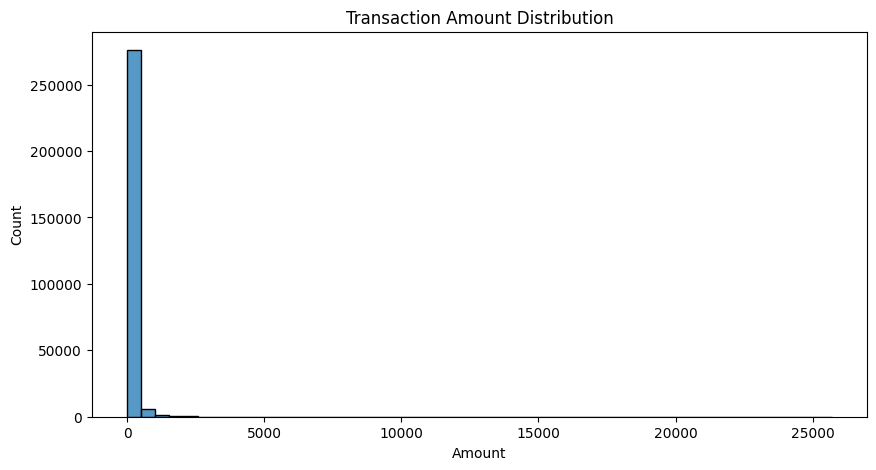

In [12]:
plt.figure(figsize=(10, 5))
sns.histplot(df["Amount"], bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.show()

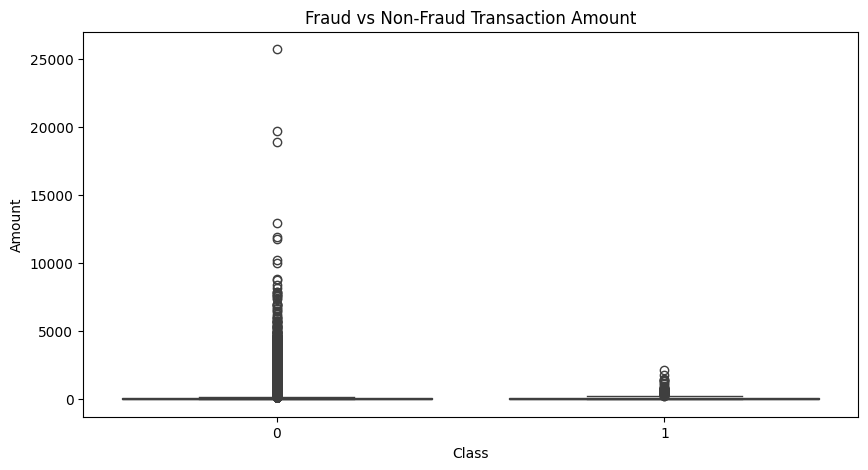

In [13]:
plt.figure(figsize=(10, 5))
sns.boxplot(x="Class", y="Amount", data=df)
plt.title("Fraud vs Non-Fraud Transaction Amount")
plt.show()

#### Observation

Fraudulent transactions tend to have different transaction amount distributions compared to normal transactions.
Several outliers are also visible in both classes.

Most fraudulent transactions occur with relatively smaller transaction amounts compared to normal transactions.
This may indicate that fraudulent activities tend to avoid unusually large amounts to reduce suspicion.

### III. Data Preprocessing

In [14]:
# 1. Remove Duplicates
print("Shape Before Removing Duplicates:", df.shape)
df = df.drop_duplicates()
print("Shape After Removing Duplicates:", df.shape)

Shape Before Removing Duplicates: (284807, 31)
Shape After Removing Duplicates: (283726, 31)


from the describe() output for Amount: The mean is ~88 but the max is 25,691. This indicates a heavy right skew.
Therefor, I use Log Trasformation

In [15]:
# 2. Log Transformation for Amount
df["Amount_Log"] = np.log1p(df["Amount"])

In [16]:
# 3. Drop Original Amount Column
df = df.drop("Amount", axis=1)

In [17]:
# Save Preprocessed Dataset

df.to_csv(
    "../data/processed/preprocessed_creditcard.csv",
    index=False
)

print("Preprocessed dataset saved successfully.")

Preprocessed dataset saved successfully.


### IV. Train Test Split

In [18]:
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\nX_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)


X_train Shape: (226980, 30)
X_test Shape: (56746, 30)


In [19]:
# Feature Scaling
scaler = StandardScaler()

columns_to_scale = ["Time", "Amount_Log"]

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [20]:
# Save Scaler
joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

['../models/scaler.pkl']

In [21]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train,
    y_train
)
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_resampled.value_counts())

Before SMOTE:
Class
0    226602
1       378
Name: count, dtype: int64

After SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64


### V. Model Training: 1. Logistic Regression

In [22]:
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_resampled, y_train_resampled)

LogisticRegression(random_state=42)

In [23]:
# Train Predictions
y_train_pred = lr_model.predict(X_train_resampled)

# Test Predictions
y_test_pred = lr_model.predict(X_test)

#### Logistic Regression Model Evaluation

In [24]:
print("=== Train Performance ===")

print("Accuracy:", accuracy_score(y_train_resampled, y_train_pred))
print("Precision:", precision_score(y_train_resampled, y_train_pred))
print("Recall:", recall_score(y_train_resampled, y_train_pred))
print("F1 Score:", f1_score(y_train_resampled, y_train_pred))

print("\nClassification Report:\n")
print(classification_report(y_train_resampled, y_train_pred))


=== Train Performance ===
Accuracy: 0.9464898809366201
Precision: 0.9725685086666325
Recall: 0.9188974501548971
F1 Score: 0.9449715111674862

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.97      0.95    226602
           1       0.97      0.92      0.94    226602

    accuracy                           0.95    453204
   macro avg       0.95      0.95      0.95    453204
weighted avg       0.95      0.95      0.95    453204



In [25]:
print("\n=== Test Performance ===")

print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("F1 Score:", f1_score(y_test, y_test_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred))


=== Test Performance ===
Accuracy: 0.9731787262538328
Precision: 0.052102950408035156
Recall: 0.8736842105263158
F1 Score: 0.09834123222748815

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.98     56746



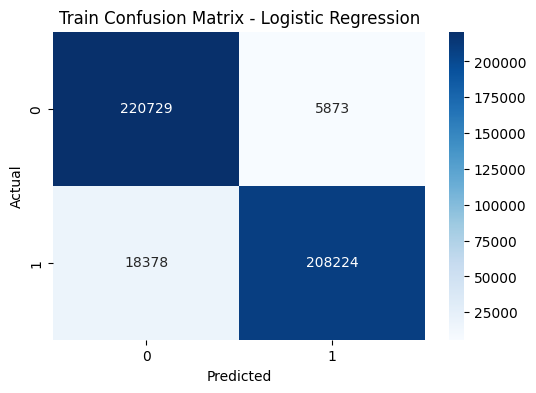

In [26]:
# Train Confusion Matrix

cm_train = confusion_matrix(
    y_train_resampled,
    y_train_pred
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_train,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Train Confusion Matrix - Logistic Regression")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

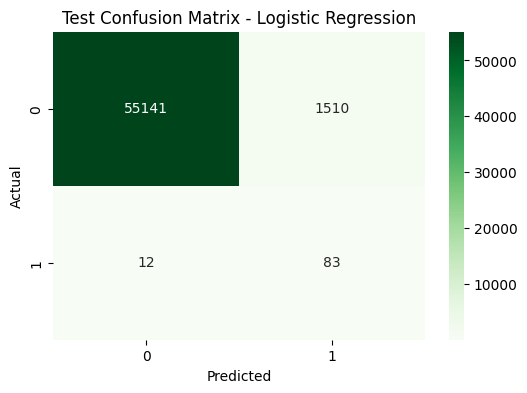

In [27]:
# Test Confusion Matrix

cm_test = confusion_matrix(
    y_test,
    y_test_pred
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_test,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Test Confusion Matrix - Logistic Regression")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#### Logistic Regression Model Optimization

In [28]:
lr_model_balanced = LogisticRegression(
    random_state=42,
    class_weight='balanced'
)

lr_model_balanced.fit(
    X_train_resampled,
    y_train_resampled
)

LogisticRegression(class_weight='balanced', random_state=42)

In [29]:
y_train_pred_balanced = lr_model_balanced.predict(X_train_resampled)

y_test_pred_balanced = lr_model_balanced.predict(X_test)

In [30]:
# Train Evaluation

print("==== Train Performance ====\n")

print("Accuracy:", accuracy_score(
    y_train_resampled,
    y_train_pred_balanced
))

print("Precision:", precision_score(
    y_train_resampled,
    y_train_pred_balanced
))

print("Recall:", recall_score(
    y_train_resampled,
    y_train_pred_balanced
))

print("F1 Score:", f1_score(
    y_train_resampled,
    y_train_pred_balanced
))

print("\nClassification Report:\n")

print(classification_report(
    y_train_resampled,
    y_train_pred_balanced
))



# Test Evaluation


print("\n\n===== Test Performance ====\n")

print("Accuracy:", accuracy_score(
    y_test,
    y_test_pred_balanced
))

print("Precision:", precision_score(
    y_test,
    y_test_pred_balanced
))

print("Recall:", recall_score(
    y_test,
    y_test_pred_balanced
))

print("F1 Score:", f1_score(
    y_test,
    y_test_pred_balanced
))

print("\nClassification Report:\n")

print(classification_report(
    y_test,
    y_test_pred_balanced
))

==== Train Performance ====

Accuracy: 0.9464898809366201
Precision: 0.9725685086666325
Recall: 0.9188974501548971
F1 Score: 0.9449715111674862

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.97      0.95    226602
           1       0.97      0.92      0.94    226602

    accuracy                           0.95    453204
   macro avg       0.95      0.95      0.95    453204
weighted avg       0.95      0.95      0.95    453204



===== Test Performance ====

Accuracy: 0.9731787262538328
Precision: 0.052102950408035156
Recall: 0.8736842105263158
F1 Score: 0.09834123222748815

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.98     56746



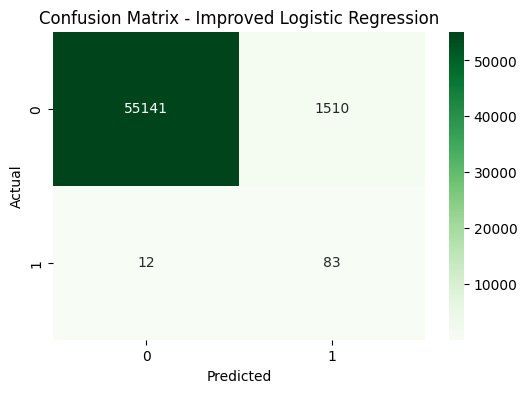

In [31]:
# Test Confusion Matrix

cm_test = confusion_matrix(
    y_test,
    y_test_pred_balanced
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_test,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Confusion Matrix - Improved Logistic Regression")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#### Model Saving

In [32]:
joblib.dump(
    lr_model_balanced,
    "../models/logistic_regression_model.pkl"
)

['../models/logistic_regression_model.pkl']

### V. Model Training: 2. Random Forest

In [33]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [34]:
rf_model.fit(
    X_train_resampled,
    y_train_resampled
)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [35]:
y_train_pred_rf = rf_model.predict(X_train_resampled)
y_test_pred_rf = rf_model.predict(X_test)

##### Random Forest Model Evaluation

In [36]:
# Train Evaluation

print("==== Train Performance ====\n")

print("Accuracy:", accuracy_score(
    y_train_resampled,
    y_train_pred_rf
))

print("Precision:", precision_score(
    y_train_resampled,
    y_train_pred_rf
))

print("Recall:", recall_score(
    y_train_resampled,
    y_train_pred_rf
))

print("F1 Score:", f1_score(
    y_train_resampled,
    y_train_pred_rf
))

print("\nClassification Report:\n")

print(classification_report(
    y_train_resampled,
    y_train_pred_rf
))

==== Train Performance ====

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    226602
           1       1.00      1.00      1.00    226602

    accuracy                           1.00    453204
   macro avg       1.00      1.00      1.00    453204
weighted avg       1.00      1.00      1.00    453204



In [37]:
# Test Evaluation

print("==== Test Performance ====\n")

print("Accuracy:", accuracy_score(
    y_test,
    y_test_pred_rf
))

print("Precision:", precision_score(
    y_test,
    y_test_pred_rf
))

print("Recall:", recall_score(
    y_test,
    y_test_pred_rf
))

print("F1 Score:", f1_score(
    y_test,
    y_test_pred_rf
))

print("\nClassification Report:\n")

print(classification_report(
    y_test,
    y_test_pred_rf
))

==== Test Performance ====

Accuracy: 0.9994713283755683
Precision: 0.922077922077922
Recall: 0.7473684210526316
F1 Score: 0.8255813953488372

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.92      0.75      0.83        95

    accuracy                           1.00     56746
   macro avg       0.96      0.87      0.91     56746
weighted avg       1.00      1.00      1.00     56746



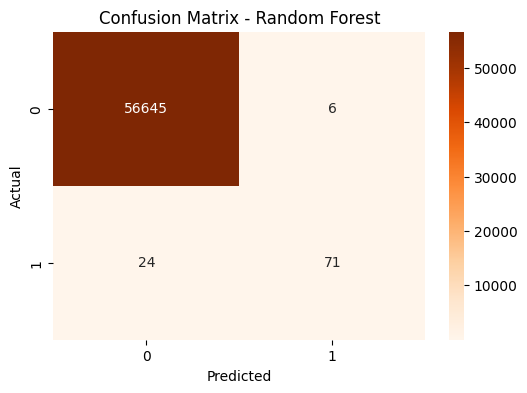

In [38]:

# Confusion Matrix

cm_test_rf = confusion_matrix(
    y_test,
    y_test_pred_rf
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_test_rf,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Confusion Matrix - Random Forest")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#### Random Forest Model Optimization

In [39]:
rf_model_improved = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

In [40]:
rf_model_improved.fit(
    X_train_resampled,
    y_train_resampled
)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=2, min_samples_split=5,
                       n_estimators=200, n_jobs=-1, random_state=42)

In [41]:
y_train_pred_rf_improved = rf_model_improved.predict(X_train_resampled)

y_test_pred_rf_improved = rf_model_improved.predict(X_test)

In [42]:
# Train Evaluation
print("==== Train Performance ====\n")

print("Accuracy:", accuracy_score(
    y_train_resampled,
    y_train_pred_rf_improved
))

print("Precision:", precision_score(
    y_train_resampled,
    y_train_pred_rf_improved
))

print("Recall:", recall_score(
    y_train_resampled,
    y_train_pred_rf_improved
))

print("F1 Score:", f1_score(
    y_train_resampled,
    y_train_pred_rf_improved
))

print("\nClassification Report:\n")

print(classification_report(
    y_train_resampled,
    y_train_pred_rf_improved
))


# Test Evaluation

print("\n\n==== Test Performance ====\n")

print("Accuracy:", accuracy_score(
    y_test,
    y_test_pred_rf_improved
))

print("Precision:", precision_score(
    y_test,
    y_test_pred_rf_improved
))

print("Recall:", recall_score(
    y_test,
    y_test_pred_rf_improved
))

print("F1 Score:", f1_score(
    y_test,
    y_test_pred_rf_improved
))

print("\nClassification Report:\n")

print(classification_report(
    y_test,
    y_test_pred_rf_improved
))

==== Train Performance ====

Accuracy: 0.9924780010767777
Precision: 0.9989314663054218
Recall: 0.9860107148215814
F1 Score: 0.9924290374950308

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99    226602
           1       1.00      0.99      0.99    226602

    accuracy                           0.99    453204
   macro avg       0.99      0.99      0.99    453204
weighted avg       0.99      0.99      0.99    453204



==== Test Performance ====

Accuracy: 0.9986783209389208
Precision: 0.5746268656716418
Recall: 0.8105263157894737
F1 Score: 0.6724890829694323

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.57      0.81      0.67        95

    accuracy                           1.00     56746
   macro avg       0.79      0.90      0.84     56746
weighted avg       1.00      1.00      1.00     56746



#### Model Saving

In [43]:
import joblib
joblib.dump(
    rf_model,
    "../models/random_forest_model.pkl"
)

print("Random Forest model saved successfully.")

Random Forest model saved successfully.


### V. Model Training: 3. XGBoost

In [44]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

In [45]:
xgb_model.fit(
    X_train_resampled,
    y_train_resampled
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=-1, num_parallel_tree=None, random_state=42, ...)

In [46]:
y_train_pred_xgb = xgb_model.predict(X_train_resampled)

y_test_pred_xgb = xgb_model.predict(X_test)

In [47]:
# Train Evaluation

print("===== Train Performance =====\n")

print("Accuracy:", accuracy_score(
    y_train_resampled,
    y_train_pred_xgb
))

print("Precision:", precision_score(
    y_train_resampled,
    y_train_pred_xgb
))

print("Recall:", recall_score(
    y_train_resampled,
    y_train_pred_xgb
))

print("F1 Score:", f1_score(
    y_train_resampled,
    y_train_pred_xgb
))

print("Classification Report:\n")

print(classification_report(
    y_train_resampled,
    y_train_pred_xgb
))


===== Train Performance =====

Accuracy: 0.9989386677964007
Precision: 0.9983075424546805
Recall: 0.9995719366995878
F1 Score: 0.9989393394797251
Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    226602
           1       1.00      1.00      1.00    226602

    accuracy                           1.00    453204
   macro avg       1.00      1.00      1.00    453204
weighted avg       1.00      1.00      1.00    453204



In [48]:

# Test Evaluation

print("==== Test Performance ====\n")

print("Accuracy:", accuracy_score(
    y_test,
    y_test_pred_xgb
))

print("Precision:", precision_score(
    y_test,
    y_test_pred_xgb
))

print("Recall:", recall_score(
    y_test,
    y_test_pred_xgb
))

print("F1 Score:", f1_score(
    y_test,
    y_test_pred_xgb
))

print("\nClassification Report:\n")

print(classification_report(
    y_test,
    y_test_pred_xgb
))

==== Test Performance ====

Accuracy: 0.9976033553025764
Precision: 0.39378238341968913
Recall: 0.8
F1 Score: 0.5277777777777778

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.39      0.80      0.53        95

    accuracy                           1.00     56746
   macro avg       0.70      0.90      0.76     56746
weighted avg       1.00      1.00      1.00     56746



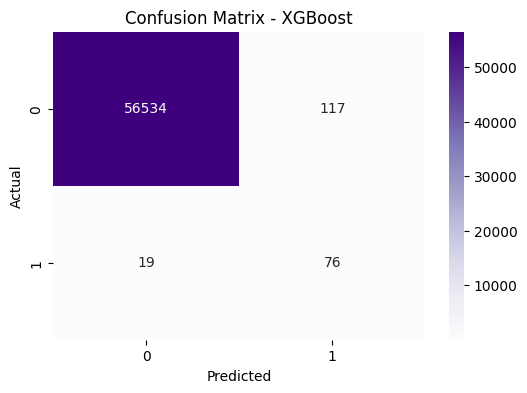

In [49]:
# Confusion Matrix
cm_test_xgb = confusion_matrix(
    y_test,
    y_test_pred_xgb
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_test_xgb,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.title("Confusion Matrix - XGBoost")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#### Optimizing XGBoost Model

In [50]:
xgb_model_improved = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=1,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

In [51]:
xgb_model_improved.fit(
    X_train_resampled,
    y_train_resampled
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=-1, num_parallel_tree=None, random_state=42, ...)

In [52]:
y_train_pred_xgb_improved = xgb_model_improved.predict(
    X_train_resampled
)

y_test_pred_xgb_improved = xgb_model_improved.predict(
    X_test
)

In [53]:
# Train Evaluation
print("==== Train Performance ====\n")

print("Accuracy:", accuracy_score(
    y_train_resampled,
    y_train_pred_xgb_improved
))

print("Precision:", precision_score(
    y_train_resampled,
    y_train_pred_xgb_improved
))

print("Recall:", recall_score(
    y_train_resampled,
    y_train_pred_xgb_improved
))

print("F1 Score:", f1_score(
    y_train_resampled,
    y_train_pred_xgb_improved
))

print("\nClassification Report:\n")

print(classification_report(
    y_train_resampled,
    y_train_pred_xgb_improved
))


# Test Evaluation

print("\n\n==== Test Performance ====\n")

print("Accuracy:", accuracy_score(
    y_test,
    y_test_pred_xgb_improved
))

print("Precision:", precision_score(
    y_test,
    y_test_pred_xgb_improved
))

print("Recall:", recall_score(
    y_test,
    y_test_pred_xgb_improved
))

print("F1 Score:", f1_score(
    y_test,
    y_test_pred_xgb_improved
))

print("\nClassification Report:\n")

print(classification_report(
    y_test,
    y_test_pred_xgb_improved
))

==== Train Performance ====

Accuracy: 0.9937754300491611
Precision: 0.9936468999960293
Recall: 0.993905614248771
F1 Score: 0.9937762402843382

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99    226602
           1       0.99      0.99      0.99    226602

    accuracy                           0.99    453204
   macro avg       0.99      0.99      0.99    453204
weighted avg       0.99      0.99      0.99    453204



==== Test Performance ====

Accuracy: 0.9933034927571988
Precision: 0.18120805369127516
Recall: 0.8526315789473684
F1 Score: 0.2988929889298893

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56651
           1       0.18      0.85      0.30        95

    accuracy                           0.99     56746
   macro avg       0.59      0.92      0.65     56746
weighted avg       1.00      0.99      1.00     56746



#### Model Saving

In [54]:
joblib.dump(
    xgb_model,
    "../models/xgboost_model.pkl"
)

print("XGBoost model saved successfully.")

XGBoost model saved successfully.


## VI. Feature Importance

In [55]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
14,V14,0.195493
10,V10,0.117545
12,V12,0.098490
17,V17,0.095142
4,V4,0.092438
11,V11,0.056594
3,V3,0.056484
16,V16,0.054607
2,V2,0.037751
9,V9,0.024837


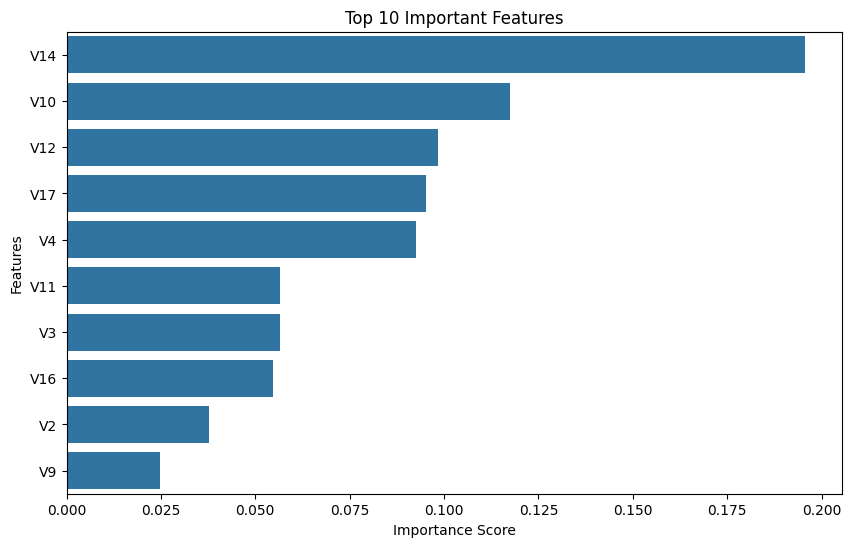

In [56]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Important Features")

plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

## VII. Final Models Comparison

In [57]:
comparison_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Improved Random Forest',
        'XGBoost',
        'Improved XGBoost'
    ],

    'Precision': [
        precision_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred_rf),
        precision_score(y_test, y_test_pred_rf_improved),
        precision_score(y_test, y_test_pred_xgb),
        precision_score(y_test, y_test_pred_xgb_improved)
    ],

    'Recall': [
        recall_score(y_test, y_test_pred),
        recall_score(y_test, y_test_pred_rf),
        recall_score(y_test, y_test_pred_rf_improved),
        recall_score(y_test, y_test_pred_xgb),
        recall_score(y_test, y_test_pred_xgb_improved)
    ],

    'F1 Score': [
        f1_score(y_test, y_test_pred),
        f1_score(y_test, y_test_pred_rf),
        f1_score(y_test, y_test_pred_rf_improved),
        f1_score(y_test, y_test_pred_xgb),
        f1_score(y_test, y_test_pred_xgb_improved)
    ]
})

comparison_df = comparison_df.sort_values(
    by='F1 Score',
    ascending=False
)

comparison_df

,Model,Precision,Recall,F1 Score
1,Random Forest,0.922078,0.747368,0.825581
2,Improved Random Forest,0.574627,0.810526,0.672489
3,XGBoost,0.393782,0.800000,0.527778
4,Improved XGBoost,0.181208,0.852632,0.298893
0,Logistic Regression,0.052103,0.873684,0.098341


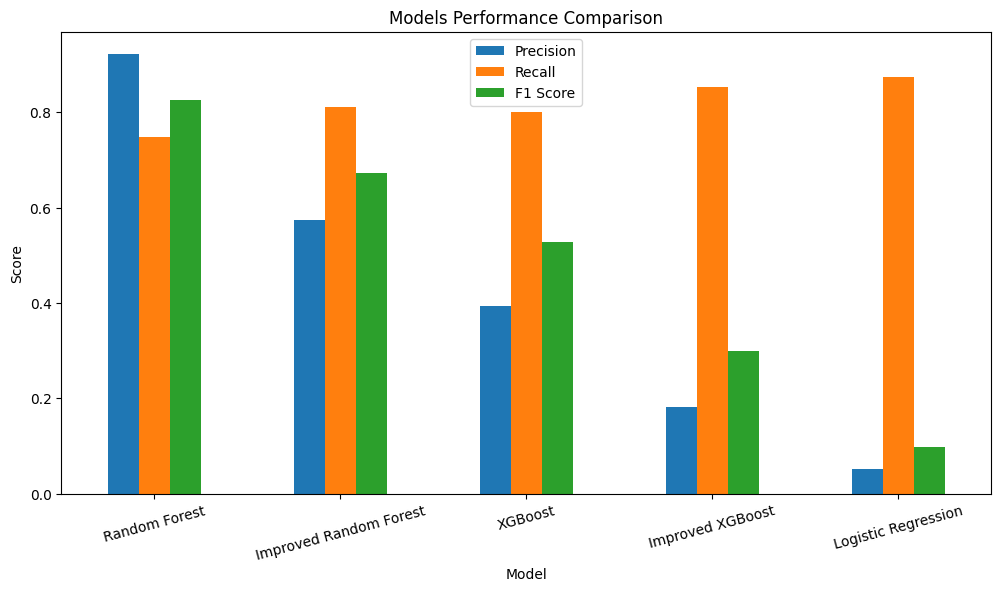

In [58]:
# Models Comparison Visualization
comparison_df.set_index('Model')[
    ['Precision', 'Recall', 'F1 Score']
].plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title("Models Performance Comparison")

plt.ylabel("Score")

plt.xticks(rotation=15)

plt.show()